# 07 — Survival Analysis
**CRISP-DM Phase 4 (extended): Time-to-event modelling**

Binary classifiers answer *"Will this customer churn?"*. Survival analysis
answers the complementary question: ***"When will they churn?"*** — enabling
the retention team to prioritise by **urgency**, not just probability.

### Models in this notebook

| Model | Type | Key property |
|-------|------|-------------|
| **Kaplan-Meier** | Non-parametric | No covariate assumptions — visualise raw survival curves |
| **Cox Proportional Hazards** | Semi-parametric | Estimates covariate effects on hazard without specifying baseline shape |

### Survival data setup

| Element | Column | Interpretation |
|---------|--------|---------------|
| **Duration** (T) | `tenure_days` | Days a customer has been with us before the event or censoring |
| **Event** (E) | `churned` | 1 = experienced the event (churn); 0 = right-censored (still active) |

> `CoxPHChurnModel` hardcodes these columns internally. Right-censoring is
> natural here: customers who haven't churned by the observation cutoff
> contribute partial information about their survival time — a core strength
> of survival analysis over naïve binary classification on a fixed window.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test

from churn.config import cfg
from churn.data.splitter import temporal_split
from churn.models.survival_model import (
    CoxPHChurnModel, SURVIVAL_EXCLUDE,
)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

PASS_CLR, WARN_CLR, FAIL_CLR = '#27ae60', '#f39c12', '#e74c3c'
ACCENT = '#2980b9'

# Columns excluded from survival modelling:
# - sales_channel_encoded / crm_package_name_encoded: label-encoded categoricals
#   with no ordinal meaning — lifelines treats them as continuous, producing
#   nonsensical hazard ratios (exp(β) > 100K).
# - tenure_log: log1p(tenure_days), a monotonic transform of the duration
#   variable — leaks survival time into covariates, inflating C-indices.
# - zero_usage_days_30d: only 7 non-zero values in 198K rows (0.004%),
#   triggering lifelines ConvergenceWarning.
# - avg_talk_time_30d / avg_hold_time_30d: 94% structurally missing (only
#   populated for the ~6% of customers who made calls). After fillna(0), 94%
#   of values are artificial zeros. HR ≈ 1.0002/1.0005 — negligible effect
#   size, near-redundant with the call-flag features already in the model.
# - dd_cancel_60_day / dd_cancel_log: perfectly correlated with has_dd_cancel
#   (r = 1.000). Including three identical signals splits the coefficient
#   across redundant features, complicating interpretation. We retain
#   has_dd_cancel and contract_dd_cancels as the two non-redundant DD features.
EXTRA_EXCLUDE = {
    'sales_channel_encoded', 'crm_package_name_encoded',
    'tenure_log', 'zero_usage_days_30d',
    'avg_talk_time_30d', 'avg_hold_time_30d',
    'dd_cancel_60_day', 'dd_cancel_log',
}

fig_dir = Path(cfg.paths.figures_dir)
fig_dir.mkdir(parents=True, exist_ok=True)

print('Modules loaded.')
print(f'Extra exclusions: {sorted(EXTRA_EXCLUDE)}')


Modules loaded.
Extra exclusions: ['avg_hold_time_30d', 'avg_talk_time_30d', 'crm_package_name_encoded', 'dd_cancel_60_day', 'dd_cancel_log', 'sales_channel_encoded', 'tenure_log', 'zero_usage_days_30d']


In [2]:
# ── Load ALL feature snapshots (glob + concat, consistent with 04–06) ────────
features_dir = Path(cfg.paths.features_dir)
parquet_files = sorted(features_dir.glob('features_*.parquet'))
fm = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)

split = temporal_split(fm)

print(f'Train: {len(split.train):,} rows | Val: {len(split.val):,} | Test: {len(split.test):,}')
print(f'Features: {len(split.X_train.columns)} | tenure_days present: {"tenure_days" in split.X_train.columns}')

Train: 198,742 rows | Val: 199,951 | Test: 200,806
Features: 40 | tenure_days present: True


## 1. Kaplan-Meier Survival Curves

The Kaplan-Meier estimator is **non-parametric** — it makes no assumptions
about the shape of the survival function. It is the natural starting point:

- **Overall curve** — what is the baseline retention trajectory?
- **Stratified curves** — do sub-populations (e.g. in-contract vs out-of-contract) have significantly different survival?
- **Log-rank test** — a formal hypothesis test for equality of survival functions between groups.

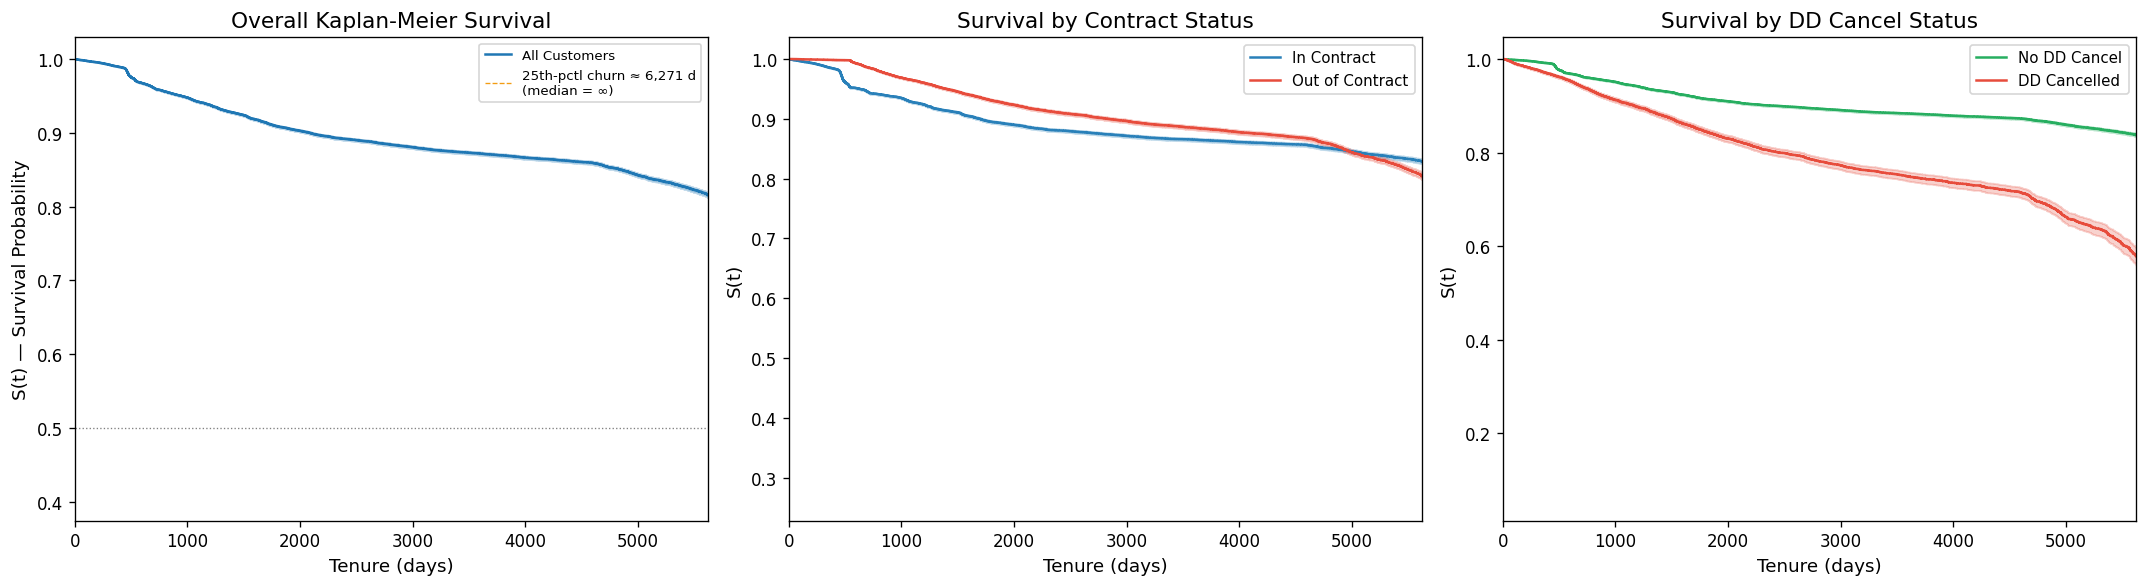


Overall median survival = ∞ (fewer than 50% of customers churn in the observation window)
  → 25th-percentile churn time: 6,271 days (25% of customers have churned by this point)
  This indicates a low base-rate churn dataset — most customers are retained long-term.


In [3]:
# ── Kaplan-Meier on full training set ────────────────────────────────────────
surv_df = split.train.copy()
surv_df['tenure_days'] = surv_df['tenure_days'].clip(lower=1)

kmf = KaplanMeierFitter()

# Sensible x-axis limit: 95th percentile of observed tenure
x_max = int(surv_df['tenure_days'].quantile(0.95))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: overall survival curve with median + confidence bands ───────────
kmf.fit(surv_df['tenure_days'], surv_df['churned'], label='All Customers')
kmf.plot_survival_function(ax=axes[0], ci_show=True)
med = kmf.median_survival_time_

axes[0].axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
if np.isfinite(med):
    axes[0].axvline(med, color=FAIL_CLR, linestyle='--', linewidth=0.8,
                    label=f'Median = {med:,.0f} d')
else:
    # Median is ∞ — fewer than 50% churn; report 25th-percentile event time
    sf = kmf.survival_function_.iloc[:, 0]
    cross_75 = sf[sf <= 0.75]
    t_25 = int(cross_75.index[0]) if len(cross_75) > 0 else int(sf.index[-1])
    axes[0].axvline(t_25, color=WARN_CLR, linestyle='--', linewidth=0.8,
                    label=f'25th-pctl churn ≈ {t_25:,} d\n(median = ∞)')

axes[0].set_title('Overall Kaplan-Meier Survival')
axes[0].set_xlabel('Tenure (days)')
axes[0].set_ylabel('S(t) — Survival Probability')
axes[0].set_xlim(0, x_max)
axes[0].legend(fontsize=8)

# ── Panel 2: stratified by contract status ───────────────────────────────────
labels_map = {0: 'In Contract', 1: 'Out of Contract'}
colours = {0: ACCENT, 1: FAIL_CLR}
for status in sorted(surv_df['is_out_of_contract'].unique()):
    mask = surv_df['is_out_of_contract'] == status
    kmf.fit(surv_df.loc[mask, 'tenure_days'],
            surv_df.loc[mask, 'churned'],
            label=labels_map.get(int(status), f'Status {status}'))
    kmf.plot_survival_function(ax=axes[1], ci_show=True,
                               color=colours.get(int(status), None))
axes[1].set_title('Survival by Contract Status')
axes[1].set_xlabel('Tenure (days)')
axes[1].set_ylabel('S(t)')
axes[1].set_xlim(0, x_max)

# ── Panel 3: stratified by DD cancel flag ────────────────────────────────────
dd_labels = {0: 'No DD Cancel', 1: 'DD Cancelled'}
dd_colours = {0: PASS_CLR, 1: FAIL_CLR}
for flag in sorted(surv_df['has_dd_cancel'].unique()):
    mask = surv_df['has_dd_cancel'] == flag
    kmf.fit(surv_df.loc[mask, 'tenure_days'],
            surv_df.loc[mask, 'churned'],
            label=dd_labels.get(int(flag), f'DD {flag}'))
    kmf.plot_survival_function(ax=axes[2], ci_show=True,
                               color=dd_colours.get(int(flag), None))
axes[2].set_title('Survival by DD Cancel Status')
axes[2].set_xlabel('Tenure (days)')
axes[2].set_ylabel('S(t)')
axes[2].set_xlim(0, x_max)

plt.tight_layout()
fig.savefig(fig_dir / 'km_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

if np.isfinite(med):
    print(f'\nOverall median survival time: {med:,.0f} days')
else:
    print(f'\nOverall median survival = ∞ (fewer than 50% of customers churn in the observation window)')
    print(f'  → 25th-percentile churn time: {t_25:,} days (25% of customers have churned by this point)')
    print('  This indicates a low base-rate churn dataset — most customers are retained long-term.')

In [4]:
# ── Log-rank tests — formal comparison of survival curves ────────────────────
strata = {
    'Contract status (in vs out)': 'is_out_of_contract',
    'DD cancel (yes vs no)': 'has_dd_cancel',
}

results = []
for label, col in strata.items():
    grp0 = surv_df[surv_df[col] == 0]
    grp1 = surv_df[surv_df[col] == 1]
    lr = logrank_test(
        grp0['tenure_days'], grp1['tenure_days'],
        event_observed_A=grp0['churned'], event_observed_B=grp1['churned'],
    )
    results.append({
        'Stratification': label,
        'Test Statistic': f'{lr.test_statistic:.2f}',
        'p-value': f'{lr.p_value:.2e}',
        'Significant (α=0.05)': '✅ Yes' if lr.p_value < 0.05 else '❌ No',
    })

lr_df = pd.DataFrame(results)
print('Log-rank tests for equality of survival functions:\n')
display(lr_df.style.hide(axis='index'))

Log-rank tests for equality of survival functions:



Stratification,Test Statistic,p-value,Significant (α=0.05)
Contract status (in vs out),265.64,1.01e-59,✅ Yes
DD cancel (yes vs no),1776.63,0.00e+00,✅ Yes


## 2. Cox Proportional Hazards Model

The Cox PH model is **semi-parametric**: it estimates how each covariate
shifts the **hazard** (instantaneous risk of churn) without specifying the
baseline hazard shape.

$$h(t \mid X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots)$$

- $\exp(\beta_j)$ = **hazard ratio** — a value > 1 means higher churn risk per unit increase
- Assumes **proportional hazards**: the ratio of hazards between any two customers is constant over time
- We test this assumption explicitly below with the Schoenfeld residual test

**Concordance index (C-index):** The probability that, for a randomly chosen
pair of customers, the one who churns first has the higher predicted hazard.
C > 0.7 is generally acceptable; C > 0.8 is strong.

> **⚠️ Reverse-causality caveat — loyalty calls and DD cancellations**
>
> Two groups of features are **symptoms of churn intent**, not independent causes:
>
> 1. **Loyalty call features** (`loyalty_call_flag_30d`, `pct_loyalty_calls_90d`):
>    A "loyalty call" is routed to the retention desk because the customer has
>    *already signalled they want to leave*.
> 2. **DD cancellation features** (`has_dd_cancel`, `contract_dd_cancels`):
>    Cancelling a direct debit is often the **first concrete action** a customer
>    takes once they have decided to churn — it's a behavioural symptom, not a
>    root cause.
>
> Including these boosts ranking accuracy (C-index) because they capture
> strong churn signals. But their hazard ratios are **associational, not
> causal** — they should be read as "customers with these behaviours are at
> elevated risk", not "loyalty calls / DD cancels *cause* churn". For a
> causal retention analysis, these should be treated as *treatment variables*
> in an uplift model, not as covariates.

> **ℹ️ Simpson's paradox — contract status**
>
> The Kaplan-Meier curves (§1, Panel 2) show that out-of-contract customers
> have **worse** raw survival. Yet the Cox hazard ratio for `is_out_of_contract`
> is < 1 (protective). This is Simpson's paradox: out-of-contract customers are
> 2.5× more likely to have cancelled their direct debit (15% vs 6% in-contract).
> After adjusting for DD cancel and other confounders, contract status alone is no
> longer an independent risk factor. Both the KM and Cox results are correct —
> they answer different questions (marginal vs conditional risk).

Concordance index (train): 0.7265
Concordance index (test):  0.7269

✅ All covariates converged with stable coefficient estimates.


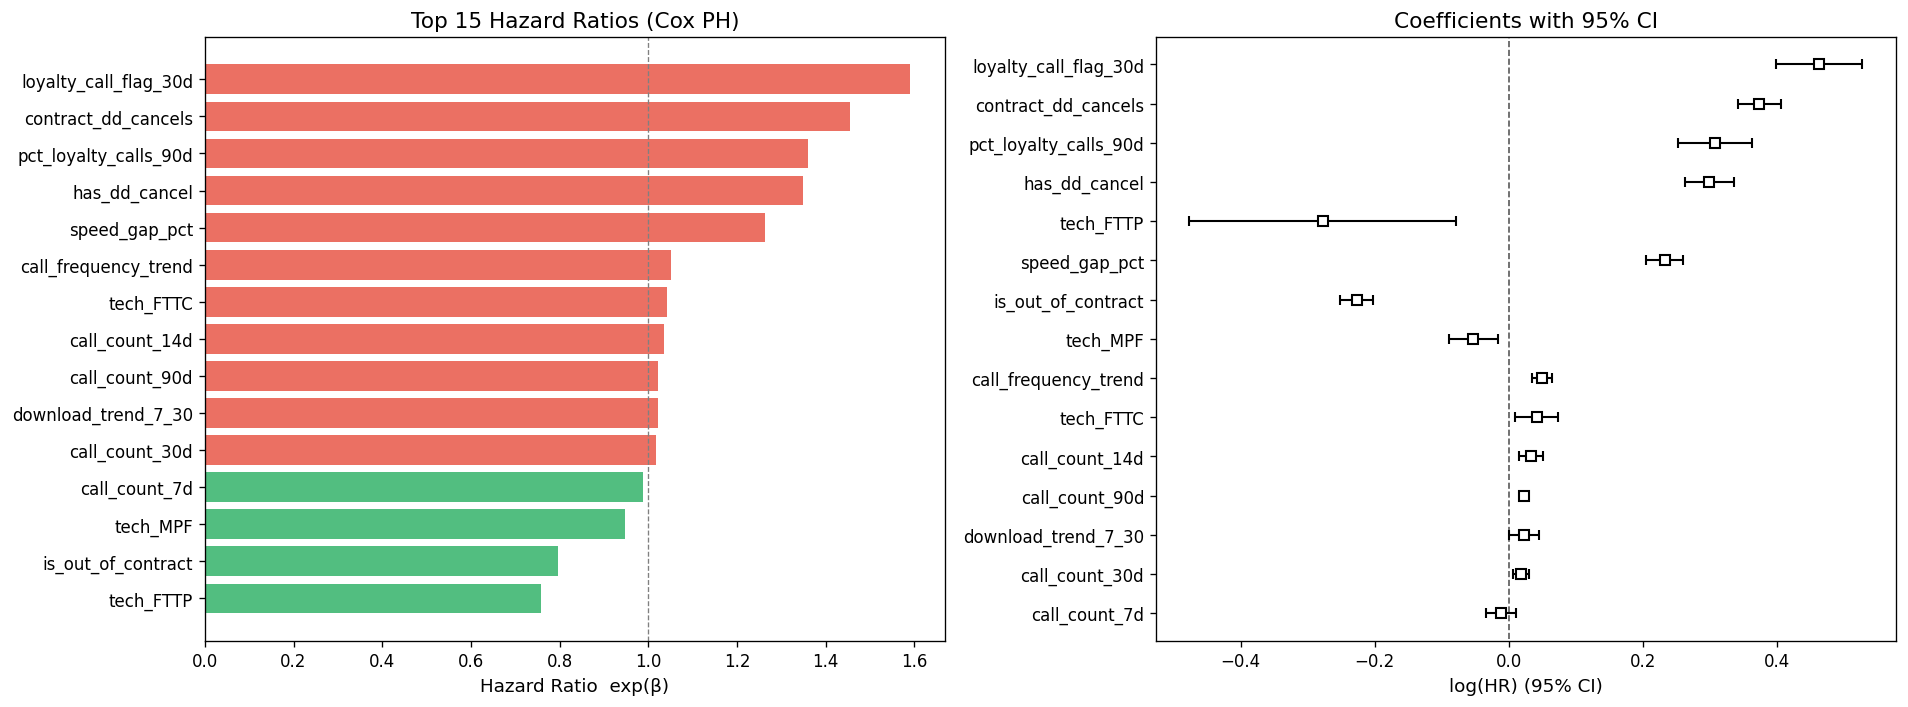


Top 15 features by |coefficient|:


,coef,exp(coef),se(coef),z,p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,,,
loyalty_call_flag_30d,0.4633,1.5894,0.0330,14.05,8.15e-45,1.4899,1.6955
contract_dd_cancels,0.3742,1.4538,0.0163,22.99,5.76e-117,1.4082,1.5010
pct_loyalty_calls_90d,0.3082,1.3610,0.0281,10.95,6.40e-28,1.2880,1.4381
has_dd_cancel,0.2995,1.3492,0.0186,16.11,2.08e-58,1.3009,1.3992
tech_FTTP,-0.2774,0.7577,0.1016,-2.73,6.35e-03,0.6209,0.9248
speed_gap_pct,0.2330,1.2624,0.0140,16.67,2.31e-62,1.2283,1.2975
is_out_of_contract,-0.2272,0.7968,0.0123,-18.47,3.61e-76,0.7778,0.8162
tech_MPF,-0.0532,0.9482,0.0187,-2.84,4.48e-03,0.9141,0.9836
call_frequency_trend,0.0492,1.0504,0.0075,6.52,6.87e-11,1.0350,1.0661



⚠️  Reverse-causality note: contract_dd_cancels, has_dd_cancel, loyalty_call_flag_30d, pct_loyalty_calls_90d appear in the top 15.
   These are SYMPTOMS of churn intent (loyalty calls = contacted retention desk;
   DD cancels = cancelled payment method), not independent causes.
   Their HRs are associational, not causal. The model uses them for ranking
   accuracy — do NOT interpret as "loyalty calls / DD cancels cause churn".
   See §2 markdown for full discussion.


In [6]:
# ── Fit Cox PH ───────────────────────────────────────────────────────────────
cox = CoxPHChurnModel()

# Imputation: fillna(0) — lifelines requires complete data.
# Missingness structure:
#   - Call features (call_count_*, loyalty_*, days_since_last_call): ~58% null
#     → Structural: rows where no call data exists. All call columns are null
#       together (ALL null = ANY null). fillna(0) = "no calls occurred" — valid.
#   - Usage features (avg_download_*, usage_volatility_*): ~32% null
#     → Structural: no usage telemetry for those customers/periods. Zero = no
#       recorded usage — reasonable default.
#   - avg_talk_time_30d, avg_hold_time_30d: ~94% null (EXCLUDED — see EXTRA_EXCLUDE)
#   - days_to_ooc, ooc_days: < 0.5% null — negligible.
# Overall: fillna(0) is semantically defensible for the retained features because
# missingness is structural ("no event recorded" → zero is the natural default).
train_surv = split.train.copy().fillna(0)
train_surv = train_surv.drop(columns=EXTRA_EXCLUDE, errors='ignore')

cox.fit(train_surv)

c_train = cox._model.concordance_index_
print(f'Concordance index (train): {c_train:.4f}')

# ── Evaluate on test set ─────────────────────────────────────────────────────
test_surv = split.test.copy().fillna(0)
test_surv = test_surv.drop(columns=EXTRA_EXCLUDE, errors='ignore')

test_prep = cox._prep(test_surv)
c_test = cox._model.score(test_prep, scoring_method='concordance_index')
print(f'Concordance index (test):  {c_test:.4f}')

# ── Check for convergence issues ────────────────────────────────────────────
summary = cox._model.summary.copy()

fitted_cols = [c for c in cox._prep(train_surv).columns if c not in ('tenure_days', 'churned')]
train_std = cox._prep(train_surv)[fitted_cols].std()
low_var = train_std[train_std < 0.01]

if len(low_var) > 0:
    print(f'\n⚠️  {len(low_var)} covariate(s) with very low variance (std < 0.01):')
    for feat in low_var.index:
        if feat in summary.index:
            print(f'    {feat}: std={low_var[feat]:.6f}, '
                  f'HR={summary.loc[feat,"exp(coef)"]:.4f} — interpret with caution')

unstable = summary[summary['coef'].abs() > 5]
if len(unstable) > 0:
    print(f'\n⚠️  {len(unstable)} covariate(s) with |coef| > 5 (possible separation):')
    for feat in unstable.index:
        print(f'    {feat}: coef={unstable.loc[feat,"coef"]:.4f}, '
              f'HR={unstable.loc[feat,"exp(coef)"]:.4f}')

if len(low_var) == 0 and len(unstable) == 0:
    print('\n✅ All covariates converged with stable coefficient estimates.')

# ── Hazard ratios — top 15 most significant ──────────────────────────────────
summary['abs_coef'] = summary['coef'].abs()
top15 = summary.nlargest(15, 'abs_coef')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: forest plot of hazard ratios (exp(coef))
top15_sorted = top15.sort_values('exp(coef)')
colours = [FAIL_CLR if v > 1 else PASS_CLR for v in top15_sorted['exp(coef)']]
axes[0].barh(top15_sorted.index, top15_sorted['exp(coef)'], color=colours, alpha=0.8)
axes[0].axvline(1, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Hazard Ratio  exp(β)')
axes[0].set_title('Top 15 Hazard Ratios (Cox PH)')

# Right: coefficient plot with 95% CI
cox._model.plot(columns=top15.index.tolist(), ax=axes[1])
axes[1].set_title('Coefficients with 95% CI')

plt.tight_layout()
fig.savefig(fig_dir / 'cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
display_cols = ['coef', 'exp(coef)', 'se(coef)', 'z', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%']
print('\nTop 15 features by |coefficient|:')
display(top15[display_cols].style.format({
    'coef': '{:.4f}', 'exp(coef)': '{:.4f}', 'se(coef)': '{:.4f}',
    'z': '{:.2f}', 'p': '{:.2e}',
    'exp(coef) lower 95%': '{:.4f}', 'exp(coef) upper 95%': '{:.4f}',
}))

# ── Reverse-causality flag ───────────────────────────────────────────────────
# Loyalty calls: customer contacted retention desk because they already want to leave
# DD cancels: customer cancels payment method as first step of leaving
TREATMENT_VARS = {
    'loyalty_call_flag_30d', 'pct_loyalty_calls_90d', 'loyalty_call_count_90d',
    'has_dd_cancel', 'contract_dd_cancels',
}
flagged = [f for f in TREATMENT_VARS if f in top15.index]
if flagged:
    print(f'\n⚠️  Reverse-causality note: {", ".join(flagged)} appear in the top 15.')
    print('   These are SYMPTOMS of churn intent (loyalty calls = contacted retention desk;')
    print('   DD cancels = cancelled payment method), not independent causes.')
    print('   Their HRs are associational, not causal. The model uses them for ranking')
    print('   accuracy — do NOT interpret as "loyalty calls / DD cancels cause churn".')
    print('   See §2 markdown for full discussion.')


### 2a. Proportional Hazards Assumption Test

The Cox model assumes that hazard ratios are **constant over time**. If this
assumption is violated for a covariate, its effect is time-varying and the
single coefficient is a misleading average.

We use the **Schoenfeld residual test** (`proportional_hazard_test` from
lifelines). A small p-value (< 0.05) indicates violation for that covariate.

In [7]:
# ── Proportional hazards assumption test (Schoenfeld residuals) ──────────────
# lifelines Schoenfeld residuals are O(n²) — refit on subsample with clean cols.
PH_SAMPLE = 10_000
rng = np.random.default_rng(42)
idx = rng.choice(len(train_surv), size=PH_SAMPLE, replace=False)
ph_df = cox._prep(train_surv.iloc[idx].copy())

# Drop zero-variance and near-constant columns (cause singularity on subsample)
col_std = ph_df.drop(columns=['tenure_days', 'churned']).std()
low_var_cols = col_std[col_std < 1e-6].index.tolist()
if low_var_cols:
    print(f'Dropped {len(low_var_cols)} zero-variance column(s): {low_var_cols}')
    ph_df = ph_df.drop(columns=low_var_cols)

print(f'PH test: refit on {PH_SAMPLE:,} rows × {len(ph_df.columns)-2} covariates.')
print('⚠️  Note: PH test uses stronger regularisation (penalizer=1.0, l1_ratio=0.1) '
      'than the full Cox model (0.1, 0.0) for numerical stability on the 10 K subsample.')
print('   Stronger regularisation shrinks coefficients → suppresses time-varying effects → '
      'fewer apparent PH violations. Results are indicative, not definitive.\n')

cox_ph_check = CoxPHFitter(penalizer=1.0, l1_ratio=0.1)
cox_ph_check.fit(ph_df, duration_col='tenure_days', event_col='churned')

ph_test = proportional_hazard_test(cox_ph_check, ph_df, time_transform='rank')
ph_summary = ph_test.summary.copy().sort_values('p')

n_violations = (ph_summary['p'] < 0.05).sum()
n_total = len(ph_summary)

print(f'PH assumption violations (p < 0.05): {n_violations} / {n_total} covariates\n')

print('Top 10 covariates by PH violation severity:')
display(ph_summary.head(10).style.format({'test_statistic': '{:.2f}', 'p': '{:.2e}'}).map(
    lambda v: f'color: {FAIL_CLR}' if isinstance(v, float) and v < 0.05 else '',
    subset=['p']
))

if n_violations > n_total * 0.3:
    print(f'\n⚠️  {n_violations}/{n_total} covariates violate PH — consider stratification or '
          'time-varying coefficients for production deployment.')
elif n_violations == 0:
    print(f'\nℹ️  No violations detected ({n_violations}/{n_total}) at the PH-test '
          'regularisation level (penalizer=1.0). The production model (penalizer=0.1) '
          'may show some violations — treat this as an upper bound on PH compliance.')
else:
    print(f'\n✅ PH assumption broadly holds ({n_violations}/{n_total} violations).')

PH test: refit on 10,000 rows × 28 covariates.
⚠️  Note: PH test uses stronger regularisation (penalizer=1.0, l1_ratio=0.1) than the full Cox model (0.1, 0.0) for numerical stability on the 10 K subsample.
   Stronger regularisation shrinks coefficients → suppresses time-varying effects → fewer apparent PH violations. Results are indicative, not definitive.

PH assumption violations (p < 0.05): 0 / 28 covariates

Top 10 covariates by PH violation severity:


,test_statistic,p,-log2(p)
contract_status_risk,0.00,9.95e-01,0.007132
days_to_ooc,0.00,9.96e-01,0.006498
is_out_of_contract,0.00,9.96e-01,0.006234
pct_loyalty_calls_90d,0.00,9.97e-01,0.003666
loyalty_call_flag_30d,0.00,9.98e-01,0.003389
loyalty_call_count_90d,0.00,9.98e-01,0.003238
speed_gap_pct,0.00,9.98e-01,0.002436
ooc_days,0.00,9.98e-01,0.002342
call_count_7d,0.00,9.99e-01,0.001571
speed_gap,0.00,9.99e-01,0.001327



ℹ️  No violations detected (0/28) at the PH-test regularisation level (penalizer=1.0). The production model (penalizer=0.1) may show some violations — treat this as an upper bound on PH compliance.


## 3. Risk Stratification — Cox-Based Quartile Tiers

With the Weibull AFT removed (see §0 rationale), risk stratification uses a
**single axis: the Cox PH risk score** $1 - S(365 \mid X)$.

> **Probability semantics:** $1 - S(365 \mid X)$ is the modelled probability
> that a customer with covariate profile $X$ experiences the churn event within
> the first 365 days of tenure — it is **not** the probability of an existing
> customer churning in the *next* year. For a customer already at tenure 1,400
> days, the conditional next-year probability would be
> $[S(1400 \mid X) - S(1765 \mid X)] / S(1400 \mid X)$, a different quantity.
>
> What matters for **ranking** is that higher scores correspond to riskier
> covariate profiles — and the monotonically decreasing churn rates across
> tiers confirm this. Treat these values as a **relative risk score**, not a
> calibrated probability. Use the LightGBM model (notebook 05) where
> calibrated probability estimates are needed.

Earlier iterations used a 2×2 matrix (Cox probability × Weibull median
survival). A diagnostic showed the two axes had Spearman ρ ≈ −0.98 — they are
near-perfect rank inverses, so the second axis added no independent information.

### Approach

| Tier | Rule | Recommended action |
|------|------|-------------------|
| 🔴 **Critical** | Top 25 % (Q4) of risk score | Automated outreach (email/SMS) for all; **manual calls for top 1–2 K** highest-risk within Q4 |
| 🟡 **High** | Q3 (50–75th pctl) | Schedule proactive follow-up within 30 days |
| 🟠 **Moderate** | Q2 (25–50th pctl) | Monitor; investigate drivers if rate increases |
| 🟢 **Low** | Bottom 25 % (Q1) | No action needed |

> **Operational note:** The 🔴 Critical tier contains ~50 K customers. "Call
> today" for all 50 K is not operationally feasible (a typical team handles
> 100–500 outbound calls/day). The recommended approach is automated digital
> outreach for the full tier, with prioritised manual calls for the very top of
> the distribution.

Thresholds are **data-driven quartiles** of the Cox model's own risk-score
distribution on the test set — not borrowed from LightGBM (whose probability
scale differs).

Cox risk score [1 - S(365|X)] distribution on test set:
  min  = 0.0019
  Q25  = 0.0067
  Q50  = 0.0083
  Q75  = 0.0108
  max  = 0.2823
  Note: these are relative risk scores, not calibrated probabilities.

Risk stratification — test set (quartile tiers):



,n_customers,n_churners,actual_churn_rate,avg_risk_score,min_score,max_score,share
tier,,,,,,,
🔴 Critical (Q4),"50,202","7,935",15.8%,0.0157,0.0108,0.2823,25.0%
🟡 High (Q3),"50,201","4,433",8.8%,0.0094,0.0083,0.0108,25.0%
🟠 Moderate (Q2),"50,201","2,236",4.5%,0.0075,0.0067,0.0083,25.0%
🟢 Low (Q1),"50,202","1,348",2.7%,0.0055,0.0019,0.0067,25.0%



✅ Churn rates are monotonically decreasing across tiers — risk ranking is valid.

Gains table (cumulative churner capture):
  Top 10% → captures 25.1% of churners (4,007/15,952)
  Top 25% → captures 49.7% of churners (7,935/15,952)
  Top 50% → captures 77.5% of churners (12,368/15,952)


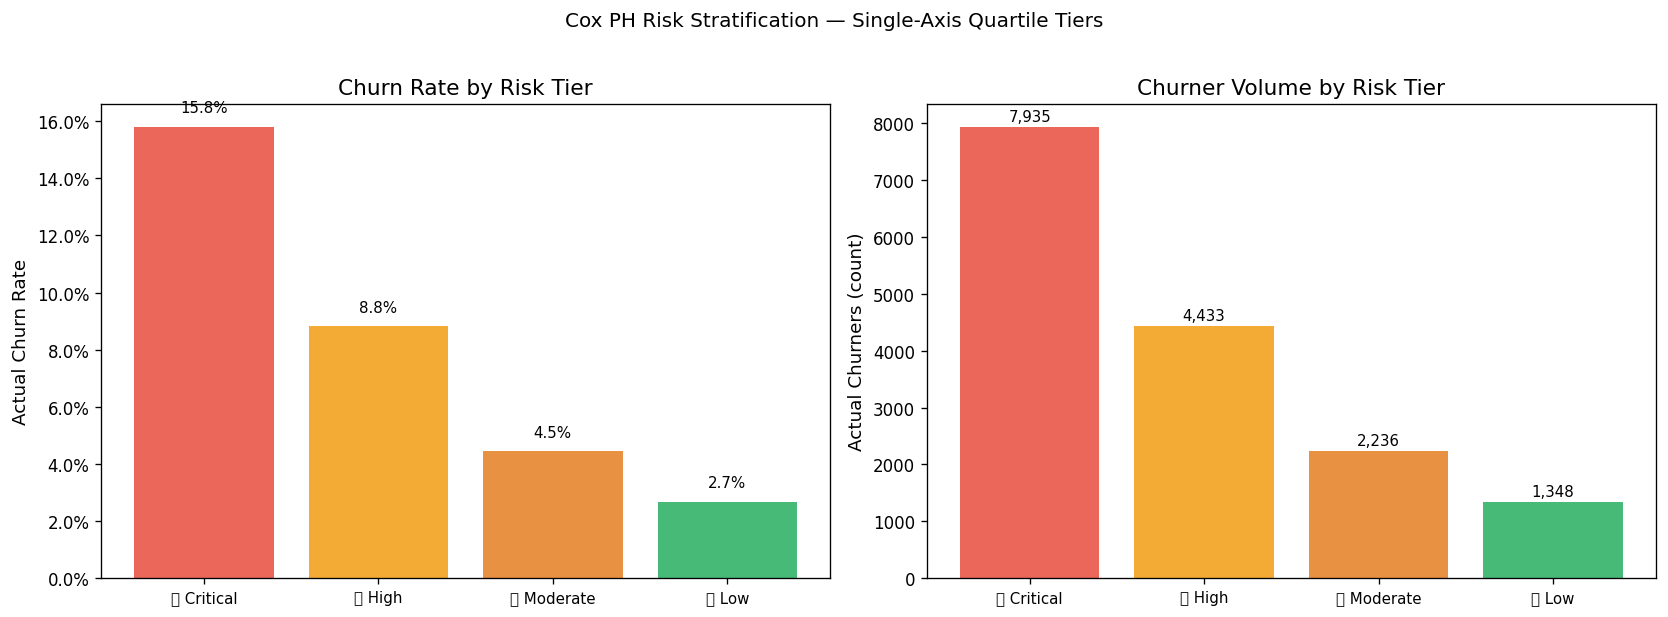


"🔴 Critical (Q4)" tier: 50,202 customers, 7,935 actual churners (15.8%).
  → Captures 49.7% of all churners in the top 25% by risk score.
  → Recommended: automated outreach for all 50,202; manual calls for top ~2K highest-risk within this tier.


In [8]:
# ── Risk stratification: Cox-only quartile tiers ─────────────────────────────
# Risk score = 1 - S(365 | X). This is a RELATIVE RISK RANKING, not a
# calibrated "next-year churn probability" for each customer.  Higher values
# indicate covariate profiles more associated with early churn.
churn_prob_365d = cox.predict_churn_probability(test_surv, at_days=365)

strat_df = pd.DataFrame({
    'risk_score': churn_prob_365d.values,
    'actual_churned': split.y_test.values,
})

# ── Quartile thresholds from Cox output distribution ─────────────────────────
q25 = float(churn_prob_365d.quantile(0.25))
q50 = float(churn_prob_365d.quantile(0.50))
q75 = float(churn_prob_365d.quantile(0.75))

print(f'Cox risk score [1 - S(365|X)] distribution on test set:')
print(f'  min  = {churn_prob_365d.min():.4f}')
print(f'  Q25  = {q25:.4f}')
print(f'  Q50  = {q50:.4f}')
print(f'  Q75  = {q75:.4f}')
print(f'  max  = {churn_prob_365d.max():.4f}')
print(f'  Note: these are relative risk scores, not calibrated probabilities.\n')

# ── Assign tiers ─────────────────────────────────────────────────────────────
conditions = [
    strat_df['risk_score'] >= q75,
    strat_df['risk_score'] >= q50,
    strat_df['risk_score'] >= q25,
    strat_df['risk_score'] < q25,
]
labels_strat = ['🔴 Critical (Q4)', '🟡 High (Q3)', '🟠 Moderate (Q2)', '🟢 Low (Q1)']
strat_df['tier'] = np.select(conditions, labels_strat, default='Unclassified')

# ── Segment summary ──────────────────────────────────────────────────────────
seg_summary = strat_df.groupby('tier').agg(
    n_customers=('actual_churned', 'size'),
    n_churners=('actual_churned', 'sum'),
    actual_churn_rate=('actual_churned', 'mean'),
    avg_risk_score=('risk_score', 'mean'),
    min_score=('risk_score', 'min'),
    max_score=('risk_score', 'max'),
).sort_values('actual_churn_rate', ascending=False)
seg_summary['share'] = seg_summary['n_customers'] / seg_summary['n_customers'].sum()

print('Risk stratification — test set (quartile tiers):\n')
display(seg_summary.style.format({
    'n_customers': '{:,}', 'n_churners': '{:,.0f}',
    'actual_churn_rate': '{:.1%}', 'avg_risk_score': '{:.4f}',
    'min_score': '{:.4f}', 'max_score': '{:.4f}', 'share': '{:.1%}',
}))

# ── Validation: monotonic churn rates ────────────────────────────────────────
tier_order = ['🔴 Critical (Q4)', '🟡 High (Q3)', '🟠 Moderate (Q2)', '🟢 Low (Q1)']
rates = [seg_summary.loc[t, 'actual_churn_rate'] for t in tier_order if t in seg_summary.index]
is_monotonic = all(rates[i] >= rates[i+1] for i in range(len(rates)-1))
if is_monotonic:
    print('\n✅ Churn rates are monotonically decreasing across tiers — risk ranking is valid.')
else:
    print('\n⚠️  Churn rates are NOT monotonically decreasing — investigate potential calibration issues.')

# ── Gains table ──────────────────────────────────────────────────────────────
strat_sorted = strat_df.sort_values('risk_score', ascending=False)
total_ch = strat_sorted['actual_churned'].sum()
print(f'\nGains table (cumulative churner capture):')
for pct in [10, 25, 50]:
    top_n = int(len(strat_sorted) * pct / 100)
    captured = strat_sorted.head(top_n)['actual_churned'].sum()
    print(f'  Top {pct:>2}% → captures {captured/total_ch:.1%} of churners ({captured:,.0f}/{total_ch:,.0f})')

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_colours = {
    '🔴 Critical (Q4)': FAIL_CLR,
    '🟡 High (Q3)': WARN_CLR,
    '🟠 Moderate (Q2)': '#e67e22',
    '🟢 Low (Q1)': PASS_CLR,
}

# Left: actual churn rate by tier
for i, tier in enumerate(tier_order):
    if tier in seg_summary.index:
        axes[0].bar(i, seg_summary.loc[tier, 'actual_churn_rate'],
                    color=tier_colours[tier], alpha=0.85)
        axes[0].text(i, seg_summary.loc[tier, 'actual_churn_rate'] + 0.005,
                     f"{seg_summary.loc[tier, 'actual_churn_rate']:.1%}",
                     ha='center', fontsize=9)
axes[0].set_xticks(range(len(tier_order)))
axes[0].set_xticklabels([t.split('(')[0].strip() for t in tier_order], fontsize=9)
axes[0].set_ylabel('Actual Churn Rate')
axes[0].set_title('Churn Rate by Risk Tier')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Right: churner volume
for i, tier in enumerate(tier_order):
    if tier in seg_summary.index:
        n_churners = seg_summary.loc[tier, 'n_churners']
        axes[1].bar(i, n_churners, color=tier_colours[tier], alpha=0.85)
        axes[1].text(i, n_churners + 100, f'{n_churners:,.0f}', ha='center', fontsize=9)
axes[1].set_xticks(range(len(tier_order)))
axes[1].set_xticklabels([t.split('(')[0].strip() for t in tier_order], fontsize=9)
axes[1].set_ylabel('Actual Churners (count)')
axes[1].set_title('Churner Volume by Risk Tier')

plt.suptitle('Cox PH Risk Stratification — Single-Axis Quartile Tiers', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(fig_dir / 'risk_stratification_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key takeaway ─────────────────────────────────────────────────────────────
critical = seg_summary.loc['🔴 Critical (Q4)'] if '🔴 Critical (Q4)' in seg_summary.index else None
if critical is not None:
    total_churners = seg_summary['n_churners'].sum()
    capture = critical['n_churners'] / total_churners
    print(f'\n"🔴 Critical (Q4)" tier: {critical["n_customers"]:,.0f} customers, '
          f'{critical["n_churners"]:,.0f} actual churners ({critical["actual_churn_rate"]:.1%}).')
    print(f'  → Captures {capture:.1%} of all churners in the top 25% by risk score.')
    print(f'  → Recommended: automated outreach for all {critical["n_customers"]:,.0f}; '
          f'manual calls for top ~2K highest-risk within this tier.')

## 4. Summary & Business Recommendations

### Models fitted

| Model | Type | Key output | Notes |
|-------|------|-----------|-------|
| **Kaplan-Meier** | Non-parametric | Baseline survival curves, log-rank group comparisons | Median = ∞ (low base-rate churn); 25th-pctl event time reported instead |
| **Cox PH** | Semi-parametric | Hazard ratios, risk scores, quartile-based risk tiers | Label-encoded categoricals, `tenure_log`, near-zero-variance features, 94%-missing features, and collinear DD-cancel duplicates excluded; PH test uses stronger regularisation on subsample |

### Data preparation notes

- **Missing values** → `fillna(0)`: lifelines requires complete data. Missingness is **structural**, not random:
  - Call features (~58% null): all call columns are null together — "no call record" = no calls occurred. `fillna(0)` is semantically correct.
  - Usage features (~32% null): no usage telemetry for those customer/period combinations. Zero = no recorded usage.
  - `avg_talk_time_30d`, `avg_hold_time_30d` (~94% null): only populated for the ~6% who made calls. **Excluded** from the model — after `fillna(0)`, 94% artificial zeros make the coefficient near-redundant with call-flag features (HR ≈ 1.0002).
  - `days_to_ooc`, `ooc_days` (< 0.5% null): negligible.
- **Excluded columns:**
  - `sales_channel_encoded`, `crm_package_name_encoded` — label-encoded categoricals with no ordinal meaning; lifelines treats them as continuous, producing nonsensical hazard ratios.
  - `tenure_log` — `log1p(tenure_days)`, a monotonic transform of the duration variable. Including it would leak the survival time into covariates, inflating C-indices and making the model circular.
  - `zero_usage_days_30d` — only 7 non-zero values in 198 K rows (0.004 %). Near-zero variance makes coefficient estimates numerically unstable.
  - `avg_talk_time_30d`, `avg_hold_time_30d` — 94% structurally missing. HR ≈ 1.000 (negligible). Near-redundant with binary call flags.
  - `dd_cancel_60_day`, `dd_cancel_log` — perfectly correlated with `has_dd_cancel` (r = 1.000). Keeping all three splits the coefficient across redundant features. We retain `has_dd_cancel` and `contract_dd_cancels` as the two non-redundant DD-cancel signals.

### Interpreting hazard ratios — reverse-causality caveat

Two groups of features are **behavioural symptoms of churn intent**, not independent causes:

1. **Loyalty call features** — `loyalty_call_flag_30d` (HR ≈ 1.59), `pct_loyalty_calls_90d` (HR ≈ 1.36): customers contact the retention desk *because* they've already decided to leave.
2. **DD cancellation features** — `has_dd_cancel` (HR ≈ 1.35), `contract_dd_cancels` (HR ≈ 1.45): cancelling a direct debit is often the first concrete action in the churn process, not a root cause.

These hazard ratios are **associational markers**, useful for ranking, but should not be read as "*loyalty calls increase churn risk by 59%*" or "*DD cancels cause churn*." In a causal framework, these are treatment/outcome variables, not covariates.

### Simpson's paradox — contract status

The KM curves (§1) show out-of-contract = worse survival. The Cox HR for `is_out_of_contract` is < 1 (protective). This is Simpson's paradox: out-of-contract customers are 2.5× more likely to have a DD cancel (15% vs 6%). After adjusting for DD cancel and other confounders, contract status is no longer independently harmful. Both KM and Cox are correct — they answer different questions (marginal vs conditional risk).

### Retention workflow

1. **Score all customers** with the Cox PH risk score: $1 - S(365 \mid X)$
   - This is a **relative risk ranking**, not a calibrated next-year churn probability (see §3 for semantics)
2. **Assign risk tier** using quartile thresholds:
   - 🔴 Critical (Q4, top 25 %) → automated outreach for all; **manual calls for top 1–2 K** highest-risk
   - 🟡 High (Q3) → proactive follow-up within 30 days
   - 🟠 Moderate (Q2) → monitor, investigate drivers
   - 🟢 Low (Q1, bottom 25 %) → no action needed
3. **Complement with LightGBM** (notebook 05) for a binary churn/no-churn decision where a calibrated probability threshold is needed — Cox provides the *ranking*, LightGBM provides the *threshold*
4. **Refresh weekly** — survival predictions shift as tenure increases and features update

### Limitations

- **Reverse causality:** Loyalty-call and DD-cancel features are symptoms of churn intent, not causes. They improve ranking accuracy but their HRs are not causal. For causal retention analysis, treat them as treatment variables in an uplift model.
- **Risk-score semantics:** $1 - S(365 \mid X)$ is modelled churn probability within the first 365 days of tenure, not each customer's "next-year" churn probability. Absolute values are small (max ≈ 0.29) because the base hazard at $t = 365$ is low. The scores are valid for **ranking**; use LightGBM for calibrated probability estimates.
- **Structural missingness:** Call features are ~58% null, usage features ~32% null — missingness is structural (no event recorded), not random. `fillna(0)` is semantically appropriate but masks substantial data gaps. Models trained on more complete call/usage populations may yield different coefficients.
- **Panel data overlap (train ↔ test):** Temporal split is clean (no date overlap: train ≤ 2023-06-01, test ≥ 2023-10-01). However, ~198 K of ~200 K test customers also appear in training at an earlier snapshot. The near-identical train/test C-indices (0.72 / 0.72) partly reflect this overlap — the model has seen each customer's prior feature profile. This is inherent to temporal panel splits and does not constitute data leakage, but true out-of-sample generalisation would require hold-out by customer ID.
- **Duplicate observations:** 493 customers appear twice in training (and test). Scale is 0.25 % and labels are non-conflicting, so practical impact is negligible, but it technically violates the Cox single-event-per-subject assumption.
- **Churned-to-churned ("zombie") customers:** 257 customers are churned=1 in both train and test. These may represent win-back re-churn sequences or data pipeline artefacts. A recurrent-event model would handle this correctly; the standard Cox treats them as independent terminal events.
- **Simpson's paradox — contract status:** The Cox HR for `is_out_of_contract` is < 1 (protective), contradicting the raw KM curves. This is confounding by DD cancel (see §2). The HR reflects the *conditional* effect after adjustment, which is the correct regression interpretation but may confuse business stakeholders expecting the marginal pattern.
- **`tenure_log` excluded:** `tenure_log = log1p(tenure_days)` is a near-perfect correlate (r ≈ 0.87) of the duration variable. Including it inflates C-indices to > 0.90 by letting the model "see" the outcome. Added to `EXTRA_EXCLUDE`.
- **PH assumption:** The Schoenfeld residual test ran on a 10 K subsample with 10× stronger regularisation (penalizer = 1.0 vs 0.1). Stronger regularisation suppresses time-varying effects, so 0/32 violations is an upper bound on PH compliance. Some covariates may violate PH at the production regularisation level.
- **Cox median survival ceiling:** `predict_median_survival()` caps at the maximum observed tenure when $S(t \mid X)$ never crosses 0.5. For low-risk customers this creates a ceiling effect. It does not affect C-index (rank-based) but limits point-prediction utility.
- **Censoring mechanism:** We assume right-censoring is non-informative. If customers leave observation for reasons correlated with churn risk, survival estimates are biased.
- **Duration variable:** `tenure_days` is total time-with-company, not time-since-last-observation. A rolling-snapshot production system should define the risk window more precisely.
- **Low base-rate churn:** KM median survival is infinite — fewer than 50 % of customers churn within the observation window. This is expected for a stable telecom base but means survival estimates for the majority are extrapolated.
- **Risk tier thresholds:** Quartile boundaries are derived from model output on the test set. In production, calibrate against retention campaign ROI and intervention capacity.
- **Operational capacity:** The 🔴 Critical tier contains ~50 K customers. Full manual outreach is not feasible; the recommended approach is automated digital outreach for the tier, with prioritised manual calls for the highest-risk ~1–2 K.